Name: Sakshi Jadhav  
Roll No.: EN23107043   
Department: AIDS-A  
Subject: AI-PD  

<h3>ASSIGNMENT NO-05</h3>

Dataset: https://www.kaggle.com/datasets/rhuebner/human-resources-data-set?resource=download

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [18]:
df = pd.read_csv("hrdata.csv")
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [19]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='object')

In [21]:
df['PerformanceScore'].unique()

array(['Exceeds', 'Fully Meets', 'Needs Improvement', 'PIP'], dtype=object)

In [22]:
le = LabelEncoder()
df['PerformanceScore'] = le.fit_transform(df['PerformanceScore'])

In [23]:
features = [
    'Salary',
    'EngagementSurvey',
    'EmpSatisfaction',
    'SpecialProjectsCount',
    'Absences',
    'DaysLateLast30'
]

X = df[features]
y = df['PerformanceScore']

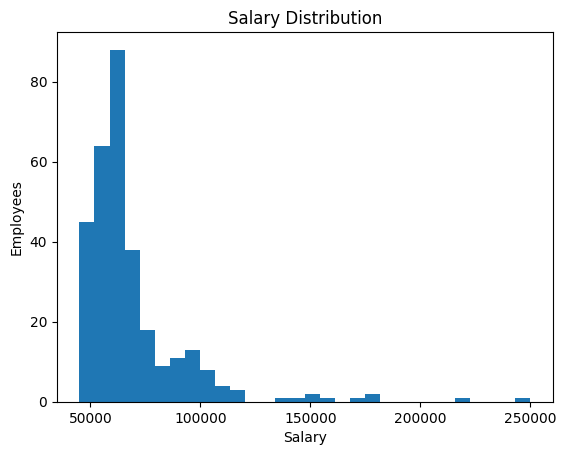

In [34]:
plt.hist(df['Salary'], bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Employees")
plt.show()

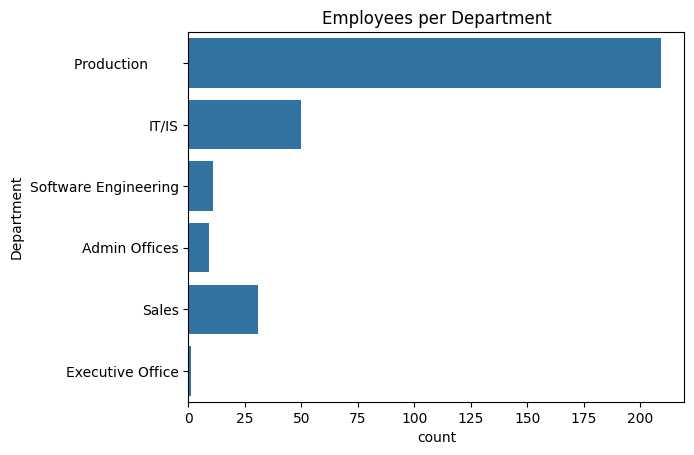

In [35]:
sns.countplot(y=df['Department'])
plt.title("Employees per Department")
plt.show()

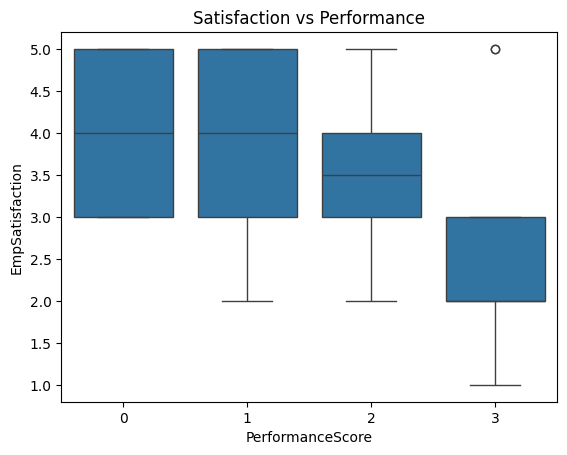

In [36]:
sns.boxplot(x=df['PerformanceScore'], y=df['EmpSatisfaction'])
plt.title("Satisfaction vs Performance")
plt.show()

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [31]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Logistic Regression\n")

print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, pred_lr, average='weighted'))
print("F1 Score:", f1_score(y_test, pred_lr, average='weighted'))

Logistic Regression

Accuracy: 0.873015873015873
Precision: 0.834920634920635
Recall: 0.873015873015873
F1 Score: 0.8374269005847953


C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\m

In [30]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("Decision Tree\n")

print("Accuracy:", accuracy_score(y_test, pred_dt))
print("Precision:", precision_score(y_test, pred_dt, average='weighted'))
print("Recall:", recall_score(y_test, pred_dt, average='weighted'))
print("F1 Score:", f1_score(y_test, pred_dt, average='weighted'))

Decision Tree

Accuracy: 0.7301587301587301
Precision: 0.824992784992785
Recall: 0.7301587301587301
F1 Score: 0.7605921855921857


C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Random Forest\n")

print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, pred_rf, average='weighted'))
print("F1 Score:", f1_score(y_test, pred_rf, average='weighted'))

Random Forest

Accuracy: 0.8888888888888888
Precision: 0.8864258347016968
Recall: 0.8888888888888888
F1 Score: 0.8762282690854118


C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


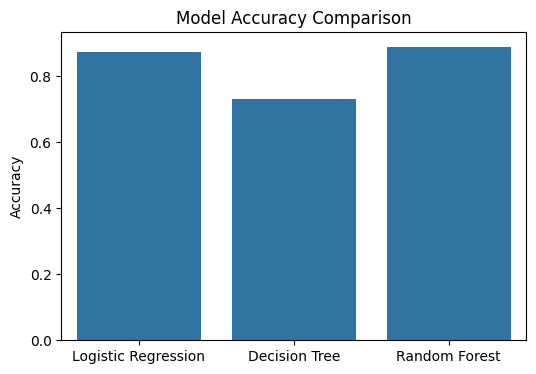

In [32]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]

accuracies = [
    accuracy_score(y_test, pred_lr),
    accuracy_score(y_test, pred_dt),
    accuracy_score(y_test, pred_rf)
]
plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

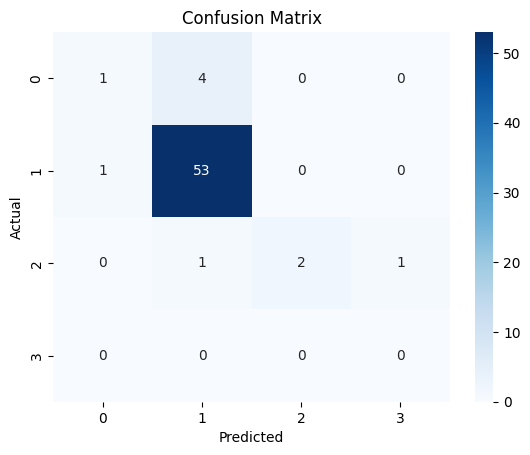

In [33]:
cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [37]:
salary = float(input("Enter Salary: "))
engagement = float(input("Enter Engagement Survey Score (1-5): "))
satisfaction = float(input("Enter Employee Satisfaction Score (1-5): "))
projects = int(input("Enter Special Projects Count: "))
absences = int(input("Enter Number of Absences: "))
late_days = int(input("Enter Days Late in Last 30 Days: "))

sample = [[salary, engagement, satisfaction, projects, absences, late_days]]
prediction = rf.predict(sample)
result = le.inverse_transform(prediction)
print("Predicted Performance:", result[0])

Enter Salary:  65000
Enter Engagement Survey Score (1-5):  4.3
Enter Employee Satisfaction Score (1-5):  4
Enter Special Projects Count:  3
Enter Number of Absences:  2
Enter Days Late in Last 30 Days:  0


Predicted Performance: Fully Meets


C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [38]:
salary = float(input("Enter Salary: "))
engagement = float(input("Enter Engagement Survey Score (1-5): "))
satisfaction = float(input("Enter Employee Satisfaction Score (1-5): "))
projects = int(input("Enter Special Projects Count: "))
absences = int(input("Enter Number of Absences: "))
late_days = int(input("Enter Days Late in Last 30 Days: "))

sample = [[salary, engagement, satisfaction, projects, absences, late_days]]
prediction = rf.predict(sample)
result = le.inverse_transform(prediction)
print("Predicted Performance:", result[0])

Enter Salary:  40000
Enter Engagement Survey Score (1-5):  2.1
Enter Employee Satisfaction Score (1-5):  2
Enter Special Projects Count:  0
Enter Number of Absences:  10
Enter Days Late in Last 30 Days:  6


Predicted Performance: PIP


C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [39]:
salary = float(input("Enter Salary: "))
engagement = float(input("Enter Engagement Survey Score (1-5): "))
satisfaction = float(input("Enter Employee Satisfaction Score (1-5): "))
projects = int(input("Enter Special Projects Count: "))
absences = int(input("Enter Number of Absences: "))
late_days = int(input("Enter Days Late in Last 30 Days: "))

sample = [[salary, engagement, satisfaction, projects, absences, late_days]]
prediction = rf.predict(sample)
result = le.inverse_transform(prediction)
print("Predicted Performance:", result[0])

Enter Salary:  70000
Enter Engagement Survey Score (1-5):  4.7
Enter Employee Satisfaction Score (1-5):  4.5
Enter Special Projects Count:  4
Enter Number of Absences:  1
Enter Days Late in Last 30 Days:  0


Predicted Performance: Fully Meets


C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
